# 01 CNN Deep Dive


##  Importing Libraries

We import the libraries used in this notebook: NumPy for arrays, Matplotlib for showing images, PIL for image conversion, and PyTorch for tensors and CNN layers.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F

## 1. Image Representation

**Definition:** A computer stores an image as a grid (array) of numbers. Each number tells how bright that small part of the picture is.

**Example:** A 5 x 5 black and white picture of a plus sign is stored as 25 numbers arranged in 5 rows and 5 columns.

**Why it is used?** A computer cannot understand a picture directly. When the picture becomes numbers, a neural network can do maths on it.

[[  0   0 255   0   0]
 [  0   0 255   0   0]
 [255 255 255 255 255]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]
Shape: (5, 5)


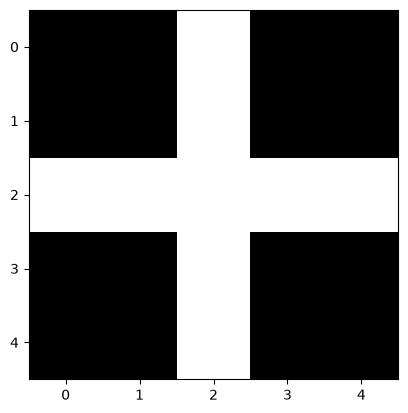

In [6]:
image = np.array([[  0,   0, 255,   0,   0],
                  [  0,   0, 255,   0,   0],
                  [255, 255, 255, 255, 255],
                  [  0,   0, 255,   0,   0],
                  [  0,   0, 255,   0,   0]])
print(image)
print("Shape:", image.shape)
plt.imshow(image, cmap="gray")
plt.show()

**Code Explanation:** The image is a NumPy array with 5 rows and 5 columns, so its shape is (5, 5). The value 255 means white and 0 means black. `plt.imshow` draws these numbers as a picture, and we can see the white plus sign on a black background.

## 2. Pixels

**Definition:** A pixel is the smallest unit of an image. It holds one number. In an 8-bit grayscale image the number goes from 0 (black) to 255 (white), and the numbers in between are shades of grey.

**Example:** In the plus sign image, the centre pixel is white (255) and the top-left corner pixel is black (0).

**Why it is used?** A CNN looks at pixels and at the relation between neighbouring pixels to find edges, shapes and objects.

In [7]:
print("Top-left pixel:", image[0, 0])
print("Centre pixel:", image[2, 2])
print("Total pixels:", image.size)
changed = image.copy()
changed[0, 0] = 128
print("Top-left pixel after change:", changed[0, 0])

Top-left pixel: 0
Centre pixel: 255
Total pixels: 25
Top-left pixel after change: 128


**Code Explanation:** We read a pixel with `image[row, column]`. The top-left pixel is 0 (black) and the centre pixel is 255 (white). The image has 25 pixels in total (5 x 5). When we set `changed[0, 0] = 128`, that pixel becomes grey. This shows that a pixel is just a number that we can read or change.

## 3. Channels

**Definition:** A channel is one layer of an image. A grayscale image has 1 channel. A colour image (RGB) has 3 channels: Red, Green and Blue. Each channel is its own grid of numbers.

**Example:** Think of a colour photo as three transparent sheets placed on top of each other: one red sheet, one green sheet and one blue sheet. Together they show the full colour picture.

**Why it is used?** Channels carry the colour information. A CNN kernel looks at all the channels together, so the number of channels is an important part of every layer.

In [8]:
rgb = np.array([[[255, 0, 0], [0, 255, 0]],
                [[0, 0, 255], [255, 255, 255]]], dtype=np.uint8)
print("Shape:", rgb.shape)
red = rgb[:, :, 0]
green = rgb[:, :, 1]
blue = rgb[:, :, 2]
print("Red channel:")
print(red)
print("Green channel:")
print(green)
print("Blue channel:")
print(blue)

Shape: (2, 2, 3)
Red channel:
[[255   0]
 [  0 255]]
Green channel:
[[  0 255]
 [  0 255]]
Blue channel:
[[  0   0]
 [255 255]]


**Code Explanation:** The shape (2, 2, 3) means 2 rows, 2 columns and 3 channels. The four pixels are red, green, blue and white. `rgb[:, :, 0]` picks the red channel, `rgb[:, :, 1]` picks the green channel and `rgb[:, :, 2]` picks the blue channel. In the red channel only the red pixel and the white pixel are 255, because only they contain red.

## 4. Grayscale vs RGB

**Definition:** A grayscale image has 1 channel (only brightness) and its shape is (Height, Width). An RGB image has 3 channels and its shape is (Height, Width, 3).

**Example:** An old black and white photo is grayscale. A photo taken with a phone camera is RGB.

**Why it is used?** Grayscale is smaller and faster to process, so it is good when colour does not matter (for example handwritten digits). RGB keeps the colour, so it is needed when colour matters (for example traffic lights or fruits).

In [9]:
pil_image = Image.fromarray(rgb)
gray = np.array(pil_image.convert("L"))
print("RGB shape :", rgb.shape)
print("Gray shape:", gray.shape)
print(gray)

RGB shape : (2, 2, 3)
Gray shape: (2, 2)
[[ 76 150]
 [ 29 255]]


**Code Explanation:** `convert("L")` changes the colour image to grayscale. It uses the formula `gray = 0.299 x Red + 0.587 x Green + 0.114 x Blue`. The shape changes from (2, 2, 3) to (2, 2), so 3 numbers per pixel become 1 number per pixel. In the output the green pixel is the lightest of the three colours (150), then red (76), and blue is the darkest (29). White stays 255.

## 5. Image Tensors

**Definition:** A tensor is a multi-dimensional array used by PyTorch. NumPy and PIL store a colour image as (Height, Width, Channels), but PyTorch wants (Channels, Height, Width). Many images together are stored as (N, Channels, Height, Width), where N is the number of images.

**Example:** A batch of 32 colour images of size 28 x 28 is a tensor of shape (32, 3, 28, 28).

**Why it is used?** PyTorch layers accept only tensors in the correct order. We also divide the pixel values by 255 so that they lie between 0 and 1, which helps the network learn.

In [10]:
np.random.seed(0)
photo = np.random.randint(0, 256, size=(4, 6, 3))
print("NumPy shape (H, W, C):", photo.shape)
tensor = torch.from_numpy(photo).float() / 255
tensor = tensor.permute(2, 0, 1)
print("Tensor shape (C, H, W):", tensor.shape)
batch = tensor.unsqueeze(0)
print("Batch shape (N, C, H, W):", batch.shape)

NumPy shape (H, W, C): (4, 6, 3)
Tensor shape (C, H, W): torch.Size([3, 4, 6])
Batch shape (N, C, H, W): torch.Size([1, 3, 4, 6])


**Code Explanation:** We start with a colour image of 4 rows, 6 columns and 3 channels. `torch.from_numpy(...).float() / 255` makes it a tensor with values between 0 and 1. `permute(2, 0, 1)` moves the channels to the front, giving (3, 4, 6). `unsqueeze(0)` adds the batch dimension, giving (1, 3, 4, 6). No numbers were lost. Only the order changed.

## 6. Convolution

**Definition:** Convolution is an operation where a small grid of numbers (called a kernel) slides over the image. At each position, the kernel numbers are multiplied with the pixels under them and all the results are added to give one number.

**Example:** Imagine a small magnifying glass moving over a picture. At every stop you write down how strongly a pattern, such as an edge, appears under the glass.

**Why it is used?** Convolution finds patterns (edges, corners, textures) anywhere in the image. The same few kernel numbers are used at every position, so the network needs far fewer weights than a normal fully connected network.

In [11]:
patch = np.array([10, 10, 0])
kernel_row = np.array([1, 0, -1])
print(patch * kernel_row)
print(np.sum(patch * kernel_row))

[10  0  0]
10


**Code Explanation:** The first line of output shows the multiplication of each pair of numbers (10 x 1 = 10, 10 x 0 = 0, 0 x -1 = 0). The second line adds them to give a single number, 10. A real convolution does exactly this for a 2D patch of the image, and repeats it at every position.

## 7. Convolution Using NumPy (Input Image -> Kernel -> Convolution -> Feature Map)

**Definition:** Here we do the full convolution by hand using NumPy, to see exactly how an input image and a kernel produce a feature map.

**Example:** We use a 5 x 5 image that is bright on the left and dark on the right, so there is a vertical edge in the middle. We use a 3 x 3 kernel made to find vertical edges. The result is a 3 x 3 feature map.

**Why it is used?** Seeing every number removes the mystery. Deep learning libraries do the same maths, only much faster.

### Step 1: Input image and kernel

In [12]:
image = np.array([[10, 10, 10, 0, 0],
                  [10, 10, 10, 0, 0],
                  [10, 10, 10, 0, 0],
                  [10, 10, 10, 0, 0],
                  [10, 10, 10, 0, 0]])
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])
print("Image shape :", image.shape)
print("Kernel shape:", kernel.shape)

Image shape : (5, 5)
Kernel shape: (3, 3)


**Code Explanation:** The image is 5 x 5 (bright 10 on the left three columns, dark 0 on the right two columns). The kernel is 3 x 3. The kernel has +1 on its left side and -1 on its right side, so it gives a big number when the left side is brighter than the right side.

### Step 2: One position at a time

In [13]:
patch1 = image[0:3, 0:3]      
patch2 = image[0:3, 1:4]      
print("Patch 1:")
print(patch1)
print("Result 1:", np.sum(patch1 * kernel))
print("Patch 2:")
print(patch2)
print("Result 2:", np.sum(patch2 * kernel))

Patch 1:
[[10 10 10]
 [10 10 10]
 [10 10 10]]
Result 1: 0
Patch 2:
[[10 10  0]
 [10 10  0]
 [10 10  0]]
Result 2: 30


**Code Explanation:** `image[0:3, 0:3]` cuts out the 3 x 3 part of the image under the kernel. We multiply it with the kernel and add everything. Patch 1 is all 10s (flat area), so the result is 0 and there is no edge. After sliding one step right, patch 2 contains the change from bright (10) to dark (0), so the result is 30, which means an edge was found.

### Step 3: All positions

In [14]:
feature_map = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        patch = image[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(patch * kernel)
print(feature_map)

[[ 0. 30. 30.]
 [ 0. 30. 30.]
 [ 0. 30. 30.]]


**Code Explanation:** The outer loop moves down the rows and the inner loop moves across the columns. At each position we cut out a 3 x 3 patch, multiply it with the kernel and add. The results are stored in `feature_map`. A 5 x 5 image with a 3 x 3 kernel gives 9 positions, so the feature map is 3 x 3. The first column is 0 (flat area) and the next two columns are 30 (the edge). Big numbers show where the pattern is found.

### Step 4: See Input Image -> Kernel -> Feature Map

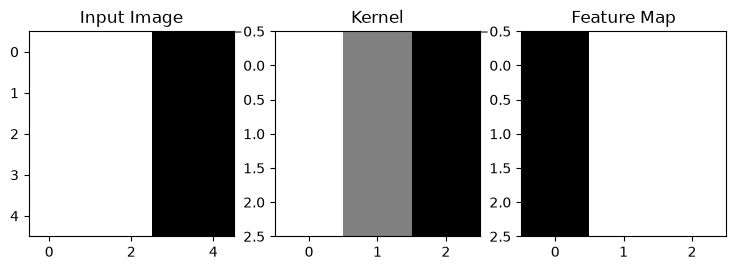

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Input Image")
ax[1].imshow(kernel, cmap="gray")
ax[1].set_title("Kernel")
ax[2].imshow(feature_map, cmap="gray")
ax[2].set_title("Feature Map")
plt.show()

**Code Explanation:** The three pictures show the full flow. On the left is the input image (bright left, dark right). In the middle is the kernel. On the right is the feature map, where the two bright columns mark the vertical edge of the input image.

## 8. Kernels / Filters

**Definition:** A kernel (also called a filter) is a small grid of numbers, usually 3 x 3, that detects one specific pattern. In a CNN the kernel numbers are not typed by hand. The network learns them during training.

**Example:** A vertical-edge kernel reacts to left-right changes in brightness. A horizontal-edge kernel reacts to top-bottom changes.

**Why it is used?** Each kernel detects a different feature. Early layers learn simple features like edges, and deeper layers combine them to detect shapes and objects.

In [16]:
img = torch.zeros(1, 1, 6, 6)
img[0, 0, 1:5, 1:5] = 1          
vertical = torch.tensor([[1., 0., -1.],
                         [1., 0., -1.],
                         [1., 0., -1.]]).reshape(1, 1, 3, 3)
horizontal = torch.tensor([[1., 1., 1.],
                           [0., 0., 0.],
                           [-1., -1., -1.]]).reshape(1, 1, 3, 3)
print("Vertical-edge kernel output:")
print(F.conv2d(img, vertical)[0, 0])
print("Horizontal-edge kernel output:")
print(F.conv2d(img, horizontal)[0, 0])

Vertical-edge kernel output:
tensor([[-2.,  0.,  0.,  2.],
        [-3.,  0.,  0.,  3.],
        [-3.,  0.,  0.,  3.],
        [-2.,  0.,  0.,  2.]])
Horizontal-edge kernel output:
tensor([[-2., -3., -3., -2.],
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [ 2.,  3.,  3.,  2.]])


**Code Explanation:** The image is a 6 x 6 picture with a white square in the middle. `F.conv2d` applies a kernel to the image (it does the same sliding and multiply-and-add we did by hand). The vertical-edge kernel gives non-zero numbers only in the first and last columns, which are the left and right sides of the square, and zeros in the middle. The horizontal-edge kernel gives non-zero numbers only in the first and last rows, which are the top and bottom sides. The positive and negative signs only show the direction of the change (dark to bright or bright to dark). The same image gives different outputs just by changing the kernel.

## 9. Feature Maps

**Definition:** A feature map is the output you get after applying one kernel to an image. It shows where in the image that kernel's pattern was found. A convolution layer with 4 kernels produces 4 feature maps. After convolution we usually apply ReLU, which changes every negative number to 0 and keeps the positive numbers.

**Example:** If a kernel detects vertical edges, its feature map has large values where vertical edges are present and small or zero values everywhere else.

**Why it is used?** Feature maps are the features the network learns. They are passed to the next layers, which combine simple features into more complex ones.

In [17]:
torch.manual_seed(0)
conv = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3)
feature_maps = conv(img)
print("Input shape :", img.shape)
print("Output shape:", feature_maps.shape)

Input shape : torch.Size([1, 1, 6, 6])
Output shape: torch.Size([1, 4, 4, 4])


**Code Explanation:** `nn.Conv2d(1, 4, 3)` creates a layer with 1 input channel and 4 kernels of size 3 x 3. The input shape is (1, 1, 6, 6): 1 image, 1 channel, 6 x 6 pixels. The output shape is (1, 4, 4, 4): 1 image and **4 feature maps**, each 4 x 4. The size becomes 4 x 4 because a 3 x 3 kernel cannot sit on the very edge of the image. The kernel numbers are random now, and training will improve them.

In [18]:
numbers = torch.tensor([-2., -1., 0., 1., 2.])
print(F.relu(numbers))

tensor([0., 0., 0., 1., 2.])


**Code Explanation:** ReLU follows the rule `max(0, x)`. The negative numbers -2 and -1 become 0, while 0, 1 and 2 stay the same. In a CNN this keeps only the positive "pattern found" signals in the feature map.

## 10. Stride

**Definition:** Stride is the number of pixels the kernel moves each time it slides. Stride 1 moves one pixel at a time and stride 2 moves two pixels at a time.

**Example:** When reading a book, stride 1 means reading every word and stride 2 means reading every second word. You finish faster but may miss some details.

**Why it is used?** A bigger stride makes the feature map smaller. This makes the network faster and uses less memory.

Output size formula (no padding): `output = (N - K) / S + 1`, where N is the image size, K is the kernel size and S is the stride (rounded down).

In [19]:
x = torch.arange(49).float().reshape(1, 1, 7, 7)
k = torch.ones(1, 1, 3, 3)
out1 = F.conv2d(x, k, stride=1)
out2 = F.conv2d(x, k, stride=2)
print("Stride 1 output shape:", out1.shape)
print("Stride 2 output shape:", out2.shape)

Stride 1 output shape: torch.Size([1, 1, 5, 5])
Stride 2 output shape: torch.Size([1, 1, 3, 3])


**Code Explanation:** The input is a 7 x 7 image and the kernel is 3 x 3. With stride 1 the output is 5 x 5, which matches the formula (7 - 3) / 1 + 1 = 5. With stride 2 the output is 3 x 3, which matches (7 - 3) / 2 + 1 = 3. A bigger stride gives a smaller feature map.

## 11. Padding

**Definition:** Padding means adding a border of zeros around the image before the convolution.

**Example:** Think of putting a photo inside a frame. The frame gives the kernel extra room to sit on the edge pixels.

**Why it is used?** Without padding the image becomes smaller after every convolution, and the edge pixels are used less than the middle pixels. With a 3 x 3 kernel and stride 1, padding = 1 keeps the output the same size as the input.

Full output size formula: `output = (N + 2P - K) / S + 1`, where P is the padding.

In [20]:
print(np.pad(np.ones((3, 3)), 1))
x = torch.ones(1, 1, 5, 5)
k = torch.ones(1, 1, 3, 3)
print("No padding :", F.conv2d(x, k, padding=0).shape)
print("Padding = 1:", F.conv2d(x, k, padding=1).shape)
print(F.conv2d(x, k, padding=1)[0, 0])

[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]
No padding : torch.Size([1, 1, 3, 3])
Padding = 1: torch.Size([1, 1, 5, 5])
tensor([[4., 6., 6., 6., 4.],
        [6., 9., 9., 9., 6.],
        [6., 9., 9., 9., 6.],
        [6., 9., 9., 9., 6.],
        [4., 6., 6., 6., 4.]])


**Code Explanation:** `np.pad` shows what padding does: a 3 x 3 image of ones gets a border of zeros and becomes 5 x 5. For the convolution, a 5 x 5 image shrinks to 3 x 3 without padding, but stays 5 x 5 with padding = 1, which matches the formula (5 + 2 - 3) / 1 + 1 = 5. In the last output the corners are 4, the edges are 6 and the middle is 9. The border values are smaller because part of the kernel is sitting on the zero border, which adds nothing.

## 12. Receptive Field

**Definition:** The receptive field of a neuron is the part of the original input image that can affect that neuron's value.

**Example:** After one 3 x 3 convolution, each output number sees a 3 x 3 area of the image. After a second 3 x 3 convolution, it sees a 5 x 5 area.

**Why it is used?** Deeper layers have a bigger receptive field, so they can recognise bigger things such as faces or wheels. It helps us decide how many layers and what kernel sizes we need.

In [21]:
size = 1
for layer in [1, 2, 3]:
    size = size + 2
    print("After conv layer", layer, "-> receptive field:", size, "x", size)

After conv layer 1 -> receptive field: 3 x 3
After conv layer 2 -> receptive field: 5 x 5
After conv layer 3 -> receptive field: 7 x 7


**Code Explanation:** We start with a receptive field of 1 pixel. Each 3 x 3 convolution adds 2 more pixels (kernel size - 1), so the receptive field grows 3 x 3, 5 x 5, 7 x 7. Pooling and stride make the receptive field grow even faster. This is why early layers see only tiny details like edges and deeper layers see larger parts of the image.

## 13. Pooling

**Definition:** Pooling makes a feature map smaller while keeping the important information. Max pooling keeps the largest number in each small window. Average pooling keeps the average of each window. A 2 x 2 window with stride 2 cuts the height and width in half.

**Example:** Divide a class into groups of 4 students. Max pooling picks the tallest student of each group, and average pooling picks the average height of each group.

**Why it is used?** It reduces the size of the data, so the network is faster. It also makes the network less sensitive to small shifts of the object. Pooling has no learnable weights.

In [22]:
fm = torch.tensor([[1., 3., 2., 4.],
                   [5., 6., 1., 2.],
                   [7., 2., 9., 0.],
                   [3., 4., 1., 8.]]).reshape(1, 1, 4, 4)
print("Max pooling:")
print(nn.MaxPool2d(2)(fm)[0, 0])
print("Average pooling:")
print(nn.AvgPool2d(2)(fm)[0, 0])

Max pooling:
tensor([[6., 4.],
        [7., 9.]])
Average pooling:
tensor([[3.7500, 2.2500],
        [4.0000, 4.5000]])


**Code Explanation:** The 4 x 4 feature map is cut into four 2 x 2 blocks, so the output of each pooling is 2 x 2. For the top-left block (1, 3, 5, 6), max pooling gives 6 (the largest) and average pooling gives 3.75 (the mean). Max pooling keeps the strongest detections, while average pooling smooths them.

## 14. Flattening

**Definition:** Flattening converts all the feature maps into one long list of numbers. It only changes the shape. No number is changed or lost.

**Example:** Two small 2 x 2 sheets of numbers become one list of 2 x 2 x 2 = 8 numbers.

**Why it is used?** Convolution and pooling layers work with 2D feature maps, but fully connected layers need a single list of numbers as input.

In [24]:
maps = torch.arange(8).float().reshape(1, 2, 2, 2)
flat = nn.Flatten()(maps)
print("Before:", maps.shape)
print("After :", flat.shape)
print(flat)

Before: torch.Size([1, 2, 2, 2])
After : torch.Size([1, 8])
tensor([[0., 1., 2., 3., 4., 5., 6., 7.]])


**Code Explanation:** `maps` holds 2 feature maps of size 2 x 2 (shape (1, 2, 2, 2)). `nn.Flatten()` turns them into a single list of 8 numbers (shape (1, 8)). The numbers 0 to 7 are the same, only now they are in one line. In a real CNN, feature maps of shape (16, 7, 7) would become a list of 16 x 7 x 7 = 784 numbers.

## 15. Fully Connected Layers

**Definition:** A fully connected (Linear or Dense) layer connects every input number to every output neuron. Each neuron multiplies the inputs with its weights, adds them up and then adds a bias.

**Example:** To decide whether to go outside, you look at the weather, your free time and your mood. You give each one an importance (weight), add them up and decide. A neuron does the same.

**Why it is used?** In a CNN the convolution layers find the features, and the fully connected layers use those features to make the final decision, such as which digit is in the image.

In [25]:
x = np.array([1, 2, 3])
weights = np.array([0.5, -1, 2])
bias = 1
print("Neuron output:", np.sum(x * weights) + bias)
fc = nn.Linear(3, 2)
print("Weights shape:", fc.weight.shape)
print("Bias shape   :", fc.bias.shape)
print("Output shape :", fc(torch.ones(1, 3)).shape)

Neuron output: 5.5
Weights shape: torch.Size([2, 3])
Bias shape   : torch.Size([2])
Output shape : torch.Size([1, 2])


**Code Explanation:** For the neuron, we calculate 1 x 0.5 + 2 x (-1) + 3 x 2 + 1 = 5.5. This is the multiply, add and add bias idea. `nn.Linear(3, 2)` is a layer with 3 inputs and 2 output neurons. It has a weight matrix of shape (2, 3), which is 6 weights, and 2 biases. So the layer turns 3 input numbers into 2 output numbers. PyTorch starts the weights with random values and training improves them.

## 16. Complete CNN Flow

**Definition:** A CNN joins all the parts we learned: convolution, ReLU, pooling, flattening and a fully connected layer.

**Example:** A 28 x 28 grayscale image of a handwritten digit goes in, and 10 scores (one for each digit 0 to 9) come out.

**Why it is used?** It shows how the shape of the data changes after every layer, which is very important when building CNNs.

In [26]:
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8 * 14 * 14, 10)
)
x = torch.randn(1, 1, 28, 28)
print("Input ->", x.shape)
for layer in model:
    x = layer(x)
    print(layer.__class__.__name__, "->", x.shape)

Input -> torch.Size([1, 1, 28, 28])
Conv2d -> torch.Size([1, 8, 28, 28])
ReLU -> torch.Size([1, 8, 28, 28])
MaxPool2d -> torch.Size([1, 8, 14, 14])
Flatten -> torch.Size([1, 1568])
Linear -> torch.Size([1, 10])


**Code Explanation:** The fake image has shape (1, 1, 28, 28). The convolution layer with 8 kernels and padding 1 gives 8 feature maps of the same size, (1, 8, 28, 28). ReLU keeps the shape. MaxPool2d(2) halves the height and width to (1, 8, 14, 14). Flatten turns this into one list of 8 x 14 x 14 = 1568 numbers. The final Linear layer gives 10 scores. The scores are random now, because the network is not trained yet.